# 第６章　分布と平均の理論計算

宇都宮大学　吉田勝俊

2026.4.13
初版2026.3.17

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm  #3Dプロットのカラーマップ
import sympy as sp  #数式処理
from IPython.display import Code

グラフの線種等の一括設定

In [2]:
from matplotlib import rcParams
rcParams['lines.linewidth']=0.5
rcParams['lines.markersize']=1.2

テキストセルで使う LaTeX マクロ

- $\newcommand{\ave}[1]{\big\langle#1\big\rangle} \ave{x}$
$\newcommand{\bm}[1]{\boldsymbol{#1}} \bm{x}$
$\newcommand{\red}[1]{\color{red}{#1}} \red{x}$
$\newcommand{\blue}[1]{\color{blue}{#1}} \blue{x}$
$\newcommand{\mat}[1]{\begin{pmatrix}#1\end{pmatrix}} \mat{x_1\\x_2}$

**授業用ライブラリを仮想マシンにインストール**

- [ランタイム](https://docs.cloud.google.com/colab/docs/runtimes?hl=ja)を起動すると，Colab クラウド上に[仮想マシン](https://ja.wikipedia.org/wiki/%E4%BB%AE%E6%83%B3%E3%83%9E%E3%82%B7%E3%83%B3)が作られます．
- ランタイムが終了すると，仮想マシンは削除され，ディスクも消失するので，<br/>次のセルは，ランタイムの起動ごとに実行する必要があります．

In [3]:
import os
repo_name   =r'kylec'
repo_url    =r'https://github.com/ktysd-lab/kylec.git'
if os.path.isdir(repo_name): #二度読み抑制，アップデートの反映
    %cd {repo_name}
    !git pull
    %cd /content
else:
    !git clone {repo_url}

Cloning into 'kylec'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 49 (delta 22), reused 31 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 9.56 KiB | 2.39 MiB/s, done.
Resolving deltas: 100% (22/22), done.


## ■ 確率分布の数理モデル（数式表現された確率密度関数）

これまでは，データを集計して**確率密度密度関数**を求めましたが，</br>
ここからは，数式表現から出発する方法を学びます．

歴史的に，様々な数式表現，すなわち確率分布の数理モデルが提案されてきました．<br/>
Sympy による数式処理を活用しながら，代表的な確率分布を見てみます．

- [SymPy](https://www.sympy.org/en/index.html)
- [sympyを使って数学をしよう！ #Python - Qiita](https://qiita.com/irisu-inwl/items/45bc2844ecc295e2abe2)

#### **》実装**

**確率密度関数 (Probability Density Function) の数式処理用モジュール：**

- `symPDFbase` 基本クラス [[source](https://github.com/ktysd-lab/kylec/blob/main/mcRDS/symPDFbase.py)]
- `symPDFs` 具体的な確率密度関数の実装 [[source](https://github.com/ktysd-lab/kylec/blob/main/mcRDS/symPDFs.py)]

インポート

In [4]:
# from kylec.mcRDS import symPDFbase  #基本クラス(symPDFs と同等なクラスのDIYに必要)
from kylec.mcRDS import symPDFs     #具体的な確率密度関数の実装

実装内容の確認

In [18]:
Code(filename='kylec/mcRDS/symPDFs.py', language='python')

#
# 2026-04-17 Katsutoshi Yoshida
# 
import sympy as sp
from . import symPDFbase

class symPDFs(symPDFbase):
    '''
    確率密度関数の定義クラス
    '''
    def uniform1d(self):
        '''
        一様分布（1変数）
        '''
        x   = sp.symbols(r'x', real=True)   #独立変数（実数）
        a   = sp.symbols(r'a', real=True)   #下限（実数）
        b   = sp.symbols(r'b', real=True)   #上限（実数）

        xs, prm = (x,), (a, b)

        # 定義式
        p = sp.Piecewise(
            (0, x < a), (1, x <= b), (0, True)
            # if x<a: y=0 elif x<=b: y=1: else y=0
        ) / sp.Abs(b-a)

        # 結果
        return {
            'name': 'Uniform (1D)',
            'p':    p,      #確率密度
            'x':    xs,     #独立変数
            'prm':  prm     #パラメータ
        }

    def gauss1d(self):
        '''
        ガウス分布（1変数）
        '''
        x   = sp.symbols(r'x', real=True)       #独立変数（実数）
        m   = sp.symbols(r'm', real=True)       #平均（実数）
        s   = sp.symbols(r's', positive=True)   #標準偏差（正の実数）

        xs, prm = (x,), (m, s)

        # 定義式
        p = sp.exp(
            -(x - m)**2 / (2 * s**2)
        ) / (sp.sqrt(2 * sp.pi) * s)

        # 結果
        return {
            'name': 'Gaussian (1D)',
            'p':    p,      #確率密度
            'x':    xs,     #独立変数
            'prm':  prm     #パラメータ
        }

    def gauss2d(self):
        '''
        ガウス分布（2変数）
        '''
        x1, x2 = sp.symbols(r'x_1, x_2', real=True)     #独立変数（実数）
        m1, m2 = sp.symbols(r'm_1, m_2', real=True)     #平均（実数）
        s1, s2 = sp.symbols(r's_1, s_2', positive=True) #標準偏差（正の実数）
        rho    = sp.symbols(r'r', positive=True)        #相関係数（1 <= rho <= 1）

        xs, prm = (x1, x2), (m1, m2, s1, s2, rho)

        # 定義式
        p = sp.exp(
            -1/(2*(1-rho**2))*(
                (x1-m1)**2/(s1**2) + (x2-m2)**2/(s2**2)
                - 2*rho*(x1-m1)*(x2-m2)/(s1*s2)
            )
        ) / (2*sp.pi*s1*s2 * sp.sqrt(1-rho**2))

        # 結果
        return {
            'name': 'Gaussian (2D)',
            'p':    p,      #確率密度
            'x':    xs,     #独立変数
            'prm':  prm     #パラメータ
        }

    def rho_dummify(self, expr):
        '''
        簡約用の正数 rho_dummy := sqrt(1-rho**2)>0
        - positive=True の変数に置き換えて Sympy に整理を促す
        '''
        rho = self.pdf['prm'][4]
        self.rho_dummy = sp.symbols(r'SQRT(1-rho2)', positive=True)
        expr = expr.subs(rho**2, 1 - self.rho_dummy**2)
        return expr

    def rho_undummify(self, expr):
        '''簡約用の正数 rho_dummy を元に戻す'''
        rho = self.pdf['prm'][4]
        expr = expr.subs(self.rho_dummy**2, 1 - rho**2)
        return expr

> ### 演習１
>
> 次のコードは，一様分布とガウス分布について，確率密度関数の数式表現と，そのグラフを出力する．
> 1. 以下のセルで実行して確認せよ．
> 2. パラメータ `prm=[...]` の値を変化させて，グラフ形状との関係を考察せよ．
>
> ```python
> def demo():
>     uniform = symPDFs('uniform1d')
>     uniform.summary()
>     uniform.plot(prm=[-1,2], dom=[-5,5], reso=500);
>
>     gauss = symPDFs('gauss1d')
>     gauss.summary()
>     gauss.plot(prm=[0,1], dom=[-5,5]);
>
> demo()
> ```


===== Uniform (1D) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

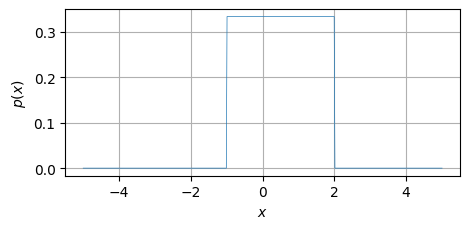

===== Gaussian (1D) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

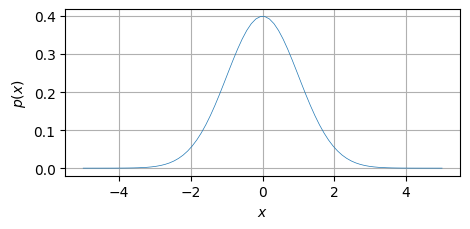

In [6]:
def demo():
    uniform = symPDFs('uniform1d')
    uniform.summary()
    uniform.plot(prm=[-1,2], dom=[-5,5], reso=500);

    gauss = symPDFs('gauss1d')
    gauss.summary()
    gauss.plot(prm=[0,1], dom=[-5,5]);

demo()

## ■ 多変数の確率密度関数

簡単のため，２変数の場合で説明します．

### ● 確率ベクトル

共通の標本空間 $\Omega$ 上で，$n$ 種類の確率変数（測定器）をとり，それらを成分とするベクトルを作ります．

$\displaystyle
\bm{x} := \mat{x_1\\ x_2}
$（マルチセンサ），
$\displaystyle
\bm{x}[\omega] := \mat{x_1[\omega]\\ x_2[\omega]}
$（測定値），$\omega\in\Omega$（標本点）


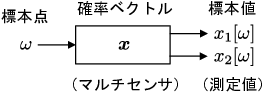

この $\bm x$ に標本点 $\omega$ を代入 $\bm x[\omega]$ すると，同時に複数の測定値 $x_1[\omega]$，$x_2[\omega]$ が出力されます．
<br/>このような**ベクトル値関数** $\bm x$ （マルチセンサ）のことを，**確率ベクトル (random vector)** と呼びます．

例）$\displaystyle
\bm x := \mat{x_1:\text{身長計}\quad\\x_2:\text{体重計}\quad}
$,　$\displaystyle
\bm x[\omega] := \mat{x_1[\omega]:\text{身長[cm]}\quad\\x_2[\omega]:\text{体重[kg]}\quad}
$,　$\omega:\text{学籍番号}$


### ● 結合確率密度関数

確率ベクトル $\bm x := (x_1,x_2)$ の確率密度関数は，$(x_1,x_2)$ 平面に浮かぶ曲面になります．
<br/>これを次のように表記し，

$p(\bm x)$,　$p(x_1,x_2)$

**結合確率密度関数 (joint PDF: joint probability density function)**，もしくは，
<br/>**多変数確率密度関数 (multivariate PDF)**
と呼びます．

> ### 演習２
>
> 次のコードは，２変数ガウス分布の結合確率密度関数の数式表現とグラフを出力する．
> 1. 以下のセルで実行して確認せよ．
> 2. パラメータ `prm=[平均1, 平均2, 標準偏差1, 標準偏差2, 相関係数]` <br/>の値を変化させて，グラフ形状との関係を考察せよ．
>
> ```python
> def demo_gauss2d():
>     pdf = symPDFs('gauss2d')
>     pdf.summary()
>     pdf.plot(prm=[0,0,1,1,-0.8], dom=[[-5,5],[-5,5]], reso=80)
>
> demo_gauss2d()
> ```


===== Gaussian (2D) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

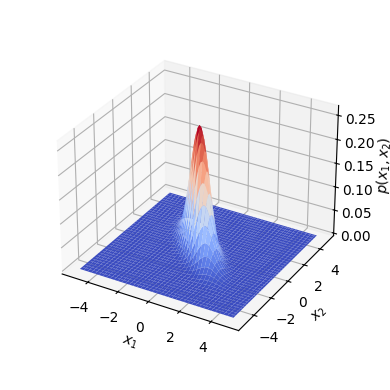

In [7]:
def demo_gauss2d():
    pdf = symPDFs('gauss2d')
    pdf.summary()
    pdf.plot(prm=[0,0,1,1,-0.8], dom=[[-5,5],[-5,5]], reso=80)

demo_gauss2d()

### ● 周辺確率密度関数

確率ベクトル $\bm x = (x_1, x_2)^T$ （$^T$ は転置）の第 $1$ 成分の分布を，<br/>
$p_1(x_1)$ で表し，$x_1$ の**周辺確率密度関数 (marginal PDF)** といいます．※$x_2$は完全無視．

同様に，第 $2$ 成分の分布を $p_2(x_2)$ で表し，$x_2$ の周辺確率密度関数といいます．※$x_1$を完全無視．




結合確率密度関数 $p(x_1,x_2)$ が数式の場合は，次式で計算します．

> **定義（周辺確率密度関数）：**
>
> - $\displaystyle
 p_1(x_1) := \int_{-\infty}^{\infty} p(x_1,x_2) dx_2
$,
> $\displaystyle
 p_2(x_2) := \int_{-\infty}^{\infty} p(x_1,x_2) dx_1
$

結合確率密度 $p(x_1, x_2)$ と，周辺確率密度 $p_1(x_1)$ の違いを模式図で示します．

- 結合確率密度 $p(x_1,x_2)$ は，$(x_1,x_2)$ 平面上に占める割合を表します．
- 周辺確率密度 $p_1(x_1)$ は，$x_1$ 軸上に占める割合を表します．

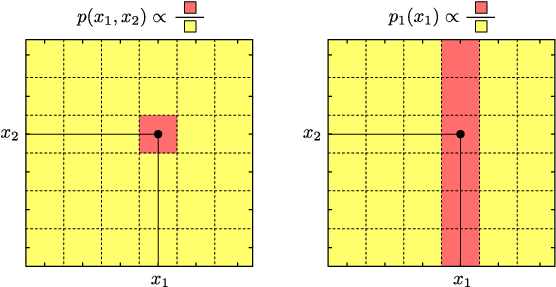

#### **》実装（２変数ガウス分布の場合）**

In [8]:
def marginal_gauss2d():
    '''
    周辺確率密度関数を計算する（２変数ガウス分布）
    '''
    pdf = symPDFs('gauss2d')

    ### 数式処理変数の取り出し ###
    p       = pdf('p').copy()       #結合確率密度の定義式
    x1, x2  = pdf('x')              #独立変数
    m1, m2, s1, s2, rho = pdf('prm')  #パラメータ
    p = pdf.rho_dummify(p)  #簡約用 dummy := sqrt(1-rho**2)>0

    def my_simplify(expr):
        expr = symPDFs.exp_simplify(expr) #結合確率密度の簡約
        expr = sp.simplify(expr)
        return expr

    ### 周辺確率密度の計算 ###
    p1 = sp.integrate(p, (x2, -sp.oo, sp.oo))
    p1 = my_simplify(p1)
    display(p1)
    pdf1 = symPDFs(
        name='Marginal Gaussian p1(x1)',
        p=p1, x=(x1,), prm=(m1,s1)
    )

    p2 = sp.integrate(p, (x1, -sp.oo, sp.oo))
    p2 = my_simplify(p2)
    pdf2 = symPDFs(
        name='Marginal Gaussian p2(x2)',
        p=p2, x=(x2,), prm=(m2,s2)
    )

    ### 比較用の1変数ガウス分布 ###
    gauss1d = symPDFs("gauss1d")
    gauss1d.replace(x=(x1,), prm=(m1,s1))

    return pdf, pdf1, pdf2, gauss1d

> ### 演習３
>
> 次のコードは，２変数ガウス分布の周辺確率密度関数を計算する．
> 1. 以下のセルで実行して確認せよ．
> 2. **演習１**の１変数ガウス分布と，式の形が一致することを確認せよ．
>
> ```python
> def demo_marginal_gauss2d():
>     pdf, pdf1, pdf2, gauss1d = marginal_gauss2d()
>     pdf.summary()     #p(x_1,x_2)
>     pdf1.summary()    #p(x_1|x_2)
>     gauss1d.summary() #一致の確認用
>
>     pdf2.summary()    #p(x_2|x_1)
>
> demo_marginal_gauss2d()
> ```


In [9]:
def demo_marginal_gauss2d():
    pdf, pdf1, pdf2, gauss1d = marginal_gauss2d()
    pdf.summary()     #p(x_1,x_2)
    pdf1.summary()    #p(x_1|x_2)
    gauss1d.summary() #一致の確認用

    pdf2.summary()    #p(x_2|x_1)

demo_marginal_gauss2d()

sqrt(2)*exp(-(m_1 - x_1)**2/(2*s_1**2))/(2*sqrt(pi)*s_1)

===== Gaussian (2D) =====


<IPython.core.display.Math object>

===== Marginal Gaussian p1(x1) =====


<IPython.core.display.Math object>

===== Gaussian (1D) =====


<IPython.core.display.Math object>

===== Marginal Gaussian p2(x2) =====


<IPython.core.display.Math object>

このように，
- ２変数ガウス分布の周辺確率密度関数は，１変数ガウス分布に帰着します．
- 一般にガウス分布の場合，$n$変数結合確率密度の全ての周辺分布は，ガウス分布になります．

$\qquad\displaystyle
p_1(x_1) :=
\int_{-\infty}^{\infty}
\cdots
\int_{-\infty}^{\infty}\left\{
    \int_{-\infty}^{\infty}\left\{
        \int_{-\infty}^{\infty}
        p(x_1,x_2,\cdots,x_n)
        dx_2
    \right\}dx_3
\right\}dx_4\cdots dx_n
$（１変数ガウス分布）

$\qquad\displaystyle
p_{12}(x_1,x_2) :=
\int_{-\infty}^{\infty}
\cdots
\int_{-\infty}^{\infty}\left\{
        \int_{-\infty}^{\infty}
        p(x_1,x_2,\cdots,x_n)
        dx_3
\right\}dx_4\cdots dx_n
$（２変数ガウス分布）以下同

### ● 条件付き確率密度関数

#### **》定義**

次式を，**条件付確率密度関数 (conditional PDF)** といいます．左辺カッコ内は「$x_1$ パイプ $x^c_2$」と読みます．

> **定義（条件付確率密度関数）：**
>
> - $\displaystyle
 p(x_1|x^c_2)
 = \frac{p(x_1,x_2^c)}{p(x_2^c)}
$
$\quad\displaystyle
\left(\text{or}\quad
p(x_2|x^c_1)
= \frac{p(x_1^c,x_2)}{p(x_1^c)}
\right)
$

$x_1$ は，条件付き確率密度関数の $x_1$ 軸であり，値は任意です．<br/>
$x^c_2$ は，特定の値で，**条件 (condition)** と呼びます．

（注）条件部分は，それと分かる印をつけず単に $p(x_1|x_2)$ と書くことも多いです．

> $p(x_1, x_2)$ と $p(x_1|\overline x^c_2)$ の違いを下図に示します．
>
> - 結合確率密度 $p(x_1,x_2)$ は，$(x_1,x_2)$ 平面に占める割合を表します．
> - 条件確率密度 $p(x_1|x^c_2)$ は，$x_2$ を特定の値 $x^c_2$ に限定したときの割合を表します．
>
> 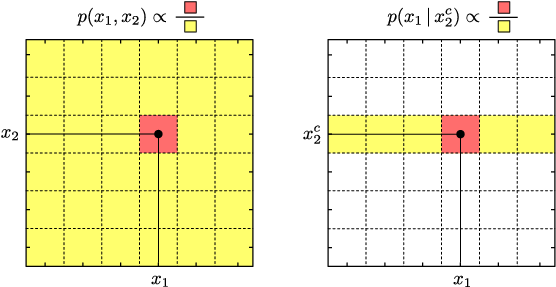

多次元の場合は，次のように拡張されます（$^c$ は省いた）．

> **定義（条件付確率密度関数：多次元）：**
>
> - $\displaystyle
 p(x_2|\blue{x_1,x_3})
 := \frac{p(x_1,x_2,x_3)}{p(\blue{x_1,x_3})}
$,　$\displaystyle
 p(x_1,x_4|\blue{x_2,x_3,x_5})
 := \frac{p(x_1,x_2,x_3,x_4,x_5)}{p(\blue{x_2,x_3,x_5})}
$

#### **》条件付き確率密度関数の公式**

定義の分母を払うと，次の公式が得られます（$^c$は省いた）．

> **公式（乗法定理）：**
>
> - $p(x_1,x_2) = p(x_1|x_2)p_2(x_2)$,　$p(x_1,x_2) = p(x_2|x_1)p_1(x_1)$


また，乗法定理の２式を $p(x_1,x_2)$ で等置すると，次の公式を得ます．

> **公式（ベイズの定理）：**
>
> - $\displaystyle p(x_2|x_1) = \frac{p_2(x_2)}{p_1(x_1)}p(x_1|x_2)$



ベイズの定理を使うと，独立変数と条件の立場（因果関係）を反転させることができます．

#### **》実装（２変数ガウス分布の場合）**

In [10]:
def conditional_gauss2d():
    '''
    条件付き確率密度関数を計算する（２変数ガウス分布）
    '''
    pdf = symPDFs('gauss2d')

    ### 数式処理変数の取り出し ###
    p       = pdf('p').copy()       #結合確率密度の定義式
    x1, x2  = pdf('x')              #独立変数
    m1, m2, s1, s2, rho = pdf('prm')  #パラメータ
    p = pdf.rho_dummify(p) #簡約用 dummy := sqrt(1-r**2)>0

    ### 条件付き確率密度の計算 ###
    # 周辺確率密度 p2(x2)
    p2 = sp.integrate(p, (x1, -sp.oo, sp.oo))
    p2 = sp.simplify(p2)

    # 条件付き確率密度
    p1pip2 = sp.simplify(p/p2)
    p1pip2 = pdf.rho_undummify(p1pip2)      #dummyを戻す
    x2c = sp.symbols(r"x_2^c", real=True)   #条件のそれ用の変数名に
    p1pip2 = p1pip2.subs(x2, x2c)
    p1pip2 = symPDFs.exp_simplify(p1pip2)

    pdf1pip2 = symPDFs(
        name='Conditional Gaussian p(x1|x2^c)',
        p=p1pip2, x=(x1,x2c), prm=pdf('prm')
    )

    return pdf, pdf1pip2

> ### 演習４
>
> 次のコードは，２変数ガウス分布の条件付き確率密度関数を計算する．
> <br/>以下のセルで実行して確認せよ．
>
> ```python
> def demo_conditional_gauss2d():
>     pdf, pdf1pip2 = conditional_gauss2d()
>
>     prm=[0,0,1,1,-0.8]
>     dom=[[-5,5],[-5,5]]
>     reso=80
>
>     pdf.summary()
>     pdf.plot(prm, dom, reso)
>
>     pdf1pip2.summary()
>     pdf1pip2.plot(prm, dom, reso, labs=[r'$x_1$', r'$x^c_2$', r'$p(x_1|x^c_2)$'])
>
> demo_conditional_gauss2d()
> ```


===== Gaussian (2D) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

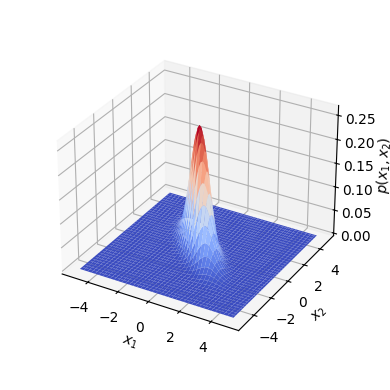

===== Conditional Gaussian p(x1|x2^c) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

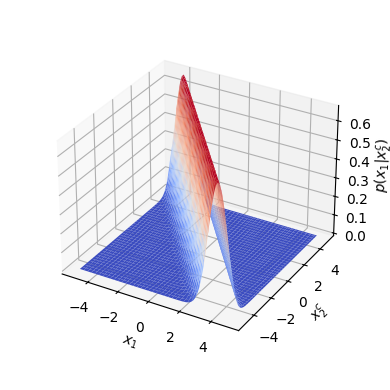

In [11]:
def demo_conditional_gauss2d():
    pdf, pdf1pip2 = conditional_gauss2d()

    prm=[0,0,1,1,-0.8]
    dom=[[-5,5],[-5,5]]
    reso=80

    pdf.summary()
    pdf.plot(prm, dom, reso)

    pdf1pip2.summary()
    pdf1pip2.plot(prm, dom, reso, labs=[r'$x_1$', r'$x^c_2$', r'$p(x_1|x^c_2)$'])

demo_conditional_gauss2d()

> ### 演習５
>
> 次のコードは，$(x_1,x_2)=(4,-4)$ における $p(x_1,x_2)$ と $p(x_1|x_2)$ の値を比較する．
> <br/>以下のセルで実行して確認せよ．
>
> ```python
> def compare_joint_conditional_gauss2d():
>     pdf, pdf1pip2 = conditional_gauss2d()
>
>     prm=[0,0,1,1,-0.8]
>     dom=[[-5,5],[-5,5]]
>     reso=80
>
>     print('===== joint PDF p(4,-4) =====')
>     print(f"{pdf.p_np(4, -4, *prm)=}\n")
>     pdf.plot(prm, dom, reso)
>
>     print('===== conditional PDF p(4|-4) =====')
>     print(f"{pdf1pip2.p_np(4, -4, *prm)=}\n")
>     pdf1pip2.plot(prm, dom, reso, labs=[r'$x_1$', r'$x^c_2$', r'$p(x_1|x^c_2)$'])
>
> compare_joint_conditional_gauss2d()
> ```


===== joint PDF p(4,-4) =====
pdf.p_np(4, -4, *prm)=array(3.65825089e-05)



<IPython.core.display.Math object>

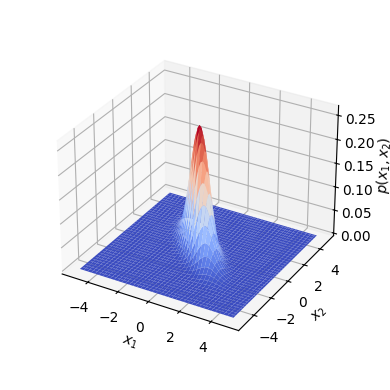

===== conditional PDF p(4|-4) =====
pdf1pip2.p_np(4, -4, *prm)=array(0.27335012)



<IPython.core.display.Math object>

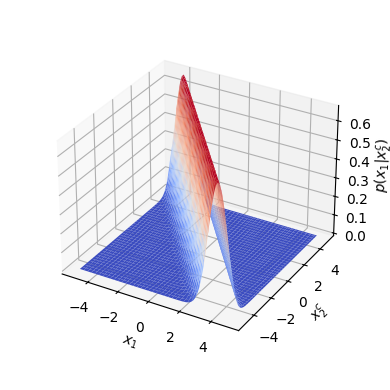

In [12]:
def compare_joint_conditional_gauss2d():
    pdf, pdf1pip2 = conditional_gauss2d()

    prm=[0,0,1,1,-0.8]
    dom=[[-5,5],[-5,5]]
    reso=80

    print('===== joint PDF p(4,-4) =====')
    print(f"{pdf.p_np(4, -4, *prm)=}\n")
    pdf.plot(prm, dom, reso)

    print('===== conditional PDF p(4|-4) =====')
    print(f"{pdf1pip2.p_np(4, -4, *prm)=}\n")
    pdf1pip2.plot(prm, dom, reso, labs=[r'$x_1$', r'$x^c_2$', r'$p(x_1|x^c_2)$'])

compare_joint_conditional_gauss2d()

**演習５の考察**

- 実行結果より，結合確率密度の値は，かなり小さいです．<br/>
$\qquad p(x_1,x_2) = p(4,-4) \approx 3.66\times 10^{-5}$<br/>
この付近の測定値は，極めて稀にしか発生しません（30万分の1）．

- その一方で，条件付き確率密度の値は，そこまで小さくありません．<br/>
$\qquad p(x_1\,|\,x^c_2) = p(4\,|\,-4) \approx 0.273$<br/>
これは，ごく稀に $x_2 = x_2^c = −4$ 付近の測定値が得られたときに，<br/>
他方の測定値が $x_1 = 4$ 付近にくる確率密度を表しており，<br/>
そうなる頻度は低くないことが分かります．

## ■ 確率変数の独立性

#### **》定義**

> **定義（独立性）：**
>
> 確率変数 $x_1[\omega]$, $x_2[\omega]$ について，結合確率密度関数 $p(x_1,x_2)$ が**変数分離**：
>
> - $p(x_1,x_2) = p_1(x_1)p_2(x_2)$
>
> できるとき，これらの確率変数は，互いに**独立 (independent)** であるという．

> **定義（独立性：多次元）：**
>
> 結合確率密度関数が，（例えば）次のように**変数分離**できるとき，
>
> - $p(x_1,x_2,x_3,x_4,x_5) = p_1(x_1,x_3,x_4)p_2(x_2,x_5)$
>
> 部分ベクトル $\bm x_1:=(x_1,x_3,x_4)^T$ と $\bm x_2:=(x_2,x_5)^T$ は，互いに**独立 (independent)** であるという．

#### **》独立性の公式**

> **公式（条件の消滅）：**
> 次の各条件は，確率変数 $x_1[\omega]$, $x_2[\omega]$ が独立であることと，それぞれ等価である．
> - $p(x_1 | x_2) = p_1(x_1)$
> - $p(x_2 | x_1) = p_2(x_2)$
>
> 同様に，次の各条件は，部分ベクトル $\bm x_1:=(x_1,x_3,x_4)^T$, $\bm x_2:=(x_2,x_5)^T$ が独立であることと，それぞれ等価である．
> - $p(x_1,x_3,x_4 | x_2,x_5) = p_1(x_1,x_3,x_4)$
> - $p(x_2,x_5 | x_1,x_3,x_4) = p_2(x_2,x_5)$

> 証明）$
 p(x_1,x_2)=p_1(x_1)p_2(x_2) \implies
 p(x_1|x_2)
 := \frac{p(x_1,x_2)}{p_2(x_2)}
  =\frac{p_1(x_1)p_2(x_2)}{p_2(x_2)} = p_1(x_1)$.<br/>
> $p(x_1|x_2)=p_1(x_1)\implies
 p_1(x_1) = p(x_1|x_2)
 := \frac{p(x_1,x_2)}{p_2(x_2)} \implies p(x_1,x_2)=p_1(x_1)p_2(x_2)$.
  

#### **》２変数ガウス分布の場合**

> ### 演習６
>
> ２変数ガウス分布に従う確率ベクトルの成分 $x_1$, $x_2$ は，相関係数が $0$ のとき，独立になる．
> <br/>以下のコードを実行して確認せよ．
>
> ```python
> def independence_gauss2d():
>     _, pdf1pip2 = conditional_gauss2d()
>
>     x1, x2 = pdf1pip2('x')
>     m1, m2, s1, s2, rho = pdf1pip2('prm')  #パラメータ
>     p = pdf1pip2('p')
>
>     # 相関係数 = 0 の代入
>     p0 = p.subs(rho, 0)
>     p0 = symPDFs.exp_simplify(p0)
>
>     pdf1pip2_r0 = symPDFs(
>         name='Independent Gaussian p_1(x1|x2) for rho=0',
>         p=p0, x=(x1,x2), prm=(m1, m2, s1, s2)
>     )
>     pdf1pip2_r0.summary()
>
>     ### 比較用の1変数ガウス分布 ###
>     gauss1d = symPDFs("gauss1d")
>     gauss1d.replace(x=(x1,), prm=(m1,s1))
>     gauss1d.summary()
>
>     print("\n..... p(x1|x2) = p1(x1) の証明 .....")
>     diff = sp.simplify(pdf1pip2_r0('p')-gauss1d('p'))
>     print(f"p(x1|x2) - p1(x1) = {diff}")
>
> independence_gauss2d()
> ```


In [13]:
def independence_gauss2d():
    _, pdf1pip2 = conditional_gauss2d()

    x1, x2 = pdf1pip2('x')
    m1, m2, s1, s2, rho = pdf1pip2('prm')  #パラメータ
    p = pdf1pip2('p')

    # 相関係数 = 0 の代入
    p0 = p.subs(rho, 0)
    p0 = symPDFs.exp_simplify(p0)

    pdf1pip2_r0 = symPDFs(
        name='Independent Gaussian p_1(x1|x2) for rho=0',
        p=p0, x=(x1,x2), prm=(m1, m2, s1, s2)
    )
    pdf1pip2_r0.summary()

    ### 比較用の1変数ガウス分布 ###
    gauss1d = symPDFs("gauss1d")
    gauss1d.replace(x=(x1,), prm=(m1,s1))
    gauss1d.summary()

    print("\n..... p(x1|x2) = p1(x1) の証明 .....")
    diff = sp.simplify(pdf1pip2_r0('p')-gauss1d('p'))
    print(f"p(x1|x2) - p1(x1) = {diff}")

independence_gauss2d()

===== Independent Gaussian p_1(x1|x2) for rho=0 =====


<IPython.core.display.Math object>

===== Gaussian (1D) =====


<IPython.core.display.Math object>


..... p(x1|x2) = p1(x1) の証明 .....
p(x1|x2) - p1(x1) = 0


**演習６の考察**

- $p(x_1|x_2) = p_1(x_1)$ が示されたので，**公式（条件の消滅）** より，$x_1$ と $x_2$ は独立です．

## ■ 期待値

前章までは，データを直接集計して平均を求めましたが，同じことは，確率分布を経由しても可能です．

特に，確率分布の数式から**理論計算した平均**のことを，**期待値 (expectation; expected-value)** といいます．<br/>
ただし，理論計算が主体の文脈では，期待値を単に平均と呼ぶこともあります．



### ● 確率分布から平均を求める

#### **》 ヒストグラムから：**

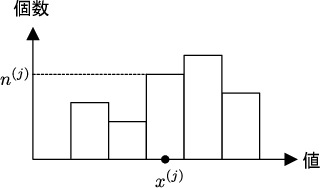

各階級の度数を $n^{(j)}$，階級値を $x^{(j)}$，階級数を $M$，標本総数を $N$ とすると，平均は次式となります．

- $\displaystyle
\ave{x} = \frac{1}{N} \sum_{j=1}^{M} x^{(j)}\cdot n^{(j)}
$
（**ヒストグラム用の公式**）


#### **》 相対度数ヒストグラムから：**

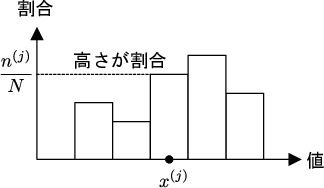

上式の$1/N$を，総和の内部に移動すると，相対度数ヒストグラム用の公式が得られます．

- $\displaystyle
\ave{x} =  \sum_{j=1}^{M} x^{(j)}\cdot \frac{n^{(j)}}{N}
$
（**相対度数ヒストグラム用の公式**）

#### **》 確率密度関数から（近似）：**

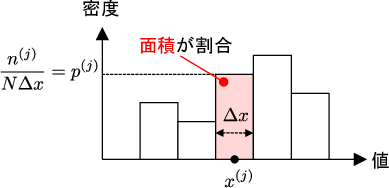

確率密度関数では，各矩形の面積 = 高さ×幅 = $p^{(j)}\Delta x$ が，**割合** $n^{(j)}/N$ を表します．
<br/>相対度数ヒストグラムの公式に代入すると，確率密度関数用の公式が得られます．

- $\displaystyle
\ave{x} =  \sum_{j=1}^{M} x^{(j)}\cdot \red{\frac{n^{(j)}}{N}}
=  \sum_{j=1}^{M} x^{(j)}\cdot \red{p^{(j)}\Delta x}
$
（**確率密度関数用の近似式**）

ただし，これは数値計算用の近似式です．数学的に厳密な式は，次に示します．

#### **》 確率密度関数から（理論計算）：**

理想的な確率密度関数 $p(x)$ が既知の場合を考えます．

$p(x)$ が既知だと，$p^{(j)}=p(x^{(j)})$ と書けるので，上述の近似式は，次のように書けます．

- $\displaystyle
\ave{x} =  \sum_{j=1}^{M} x^{(j)}\cdot \red{p^{(j)}\Delta x}
=  \sum_{j=1}^{M} x^{(j)}\cdot \red{p(x^{(j)})\Delta x}
$
（**確率密度関数用の近似式２**）

これに，**総和から積分への書き換え**を適用すると，

> **総和から積分への書き換え**
>
> $\displaystyle\quad\fbox{$
> \blue{\sum_{j=1}^{M}} f(x^{(j)}) \Delta x
> \;
> \xrightarrow[\Delta x\to 0]{M\to\infty}
> \;
> \blue{\int_{a}^{b}} f(x) d x
> $}$
>
> 1. 総和記号 $\displaystyle \sum_{j=1}^{M}$ を，積分記号 $\int_{a}^{b}$ に書き直す．
> 2. 階級値の列 $x^{(j)}$ を，連続的な変数 $x$ に書き直す．
> 3. 微小幅 $\Delta x$ を，無限小 $dx$ に書き直す．
>
> ※積分記号を $\int dx$ で理解せずに，連続的な総和記号 $\int \approx \sum$ だと思うとよい．



$\displaystyle\quad
\ave{x} =
\blue{\sum_{i=1}^{m}} x^{(j)}\,p(x^{(j)}) \Delta x
\;
\xrightarrow[\Delta x\to 0]{m\to\infty}
\;
\blue{\int_{-\infty}^{\infty}} x\,p(x) d x
$　より

- $\displaystyle
\ave{x} = \int_{-\infty}^{\infty} x\,p(x) d x$（**確率密度関数用の厳密式**）

を得ます．$p(x)$ の裾野がどれだけ広くてもカバーできるように，積分区間は $\pm\infty$ とされます．

#### **》 平均操作（理論計算）**：

以上の計算法を，**平均操作 (averaging)** として，取り分けておきます．<br/>$\phi(x)$ は任意の関数です（無限大にならないようなもの）．

- $\displaystyle
\ave{\phi(x)} := \int_{-\infty}^{\infty} \phi(x)\,p(x) d x
$

また，非定常確率密度関数 $p(x,i)$ の場合は，次のように平均します．

- $\displaystyle
\ave{\phi\big(x[\blue i]\big)} := \red{\int_{-\infty}^{\infty}} \phi(\red{x})\,p(\red{x},\blue i) d \red{x}
$

時刻 $\blue i$ を付ける場所が，釈然としないかも知れませんが，
- 積分の中の $\red x$ は，被積分関数の $x$ 軸に過ぎないので，時刻 $\blue i$ はつけません．
- 確率過程（標本路の束）の時間的変動は，$p(x,\blue i)$ の時刻 $\blue i$ が担当します．

> **平均操作 $\ave{\cdot}$ の公式：**
>
> 定数 $a$ と確率過程 $x[\omega,i]$, $y[\omega,i]$について，これまでと同形の公式が成立します．
>
> - $\ave{a}= a$
> - $\ave{ax[i]}= a\ave{x[i]}$
> - $\ave{x[i] + y[i]}=\ave{x[i]}+\ave{y[i]}$
>
> 証明） $\displaystyle \ave{a\, x[i]} := \int_{-\infty}^{\infty} ax\,p(x,i)dx= a\int_{-\infty}^{\infty} x\,p(x,i)dx  = a\ave{x[i]}$ ※他も同様

### ● 各種統計量（理論計算）

非定常確率密度関数 $p(x,i)$ が既知な場合で示します．

式の形は**第５章**と同じで，意味するところも同じですが，<br/>
平均操作 $\ave{\cdot}$ の定義が積分に変更されています．

##### **期待値 (expected value)：**
$\qquad\displaystyle m_x[\blue i] := \ave{x[\blue i]}
\qquad\left(:=\red{\int_{-\infty}^{\infty}} \red{x}\,p(\red x,\blue i) d \red{x}\right)$

##### **$n$次モーメント (momeni)：**
$\qquad m^{(n)}_x[i] := \ave{x^n[i]}$

##### **中心 $n$ 次モーメント ($n$th central momeni)：**
$\qquad \sigma^{(n)}_x[i] := \ave{(x[i]-m_x[i])^n}$

##### **分散 (variance)：**
$\qquad \sigma^2_x[i] := \ave{(x[i]-m_x[i])^2}$

##### **標準偏差 (standard deviation, SD)：**
$\qquad \sigma_x[i]:=\sqrt{\sigma_x^2[i]}$


##### **共分散 (covariance)：**
$\qquad \sigma_{xy}[i] := \ave{(x[i]-m_x[i])(y[i]-m_y[i])}$

##### **相関係数 (correlation coefficient)：**
$\qquad\displaystyle\rho_{xy}[i] := \left\langle \frac{(x[i]-m_x[i])}{\sigma_x[i]}\frac{(y[i]-m_y[i])}{\sigma_y[i]}\right\rangle
=
\frac{\sigma_{xy}[i]}{\sigma_x[i]\sigma_y[i]}$

##### **自己共分散関数 (ACVF)：**
$\qquad
C_{xx}[i,k]
:=
\ave{(x[i]-m_x[i])(x[i+k]-m_x[i])}
$

##### **自己相関関数 (ACF)：**
$\qquad\displaystyle
R_{xx}[i,k]
:=
\frac{C_{xx}[i,k]}{\sigma^2_x[i]}
=
\frac{C_{xx}[i,k]}{C_{xx}[i,0]}
$


> ### 演習７
>
> 次のコードは，数式処理によって，期待値と分散を理論計算する．
> <br/>計算結果は，ガウス分布のパラメータ $m, s$ （平均値，標準偏差）と整合するはずである．
> <br/>以下のセルで実行して，結果を確認せよ．
>
> ```python
> def averaging_gauss():
>     pdf = symPDFs('gauss1d')
>     pdf.summary()
>
>     p   = pdf('p') #確率密度関数の定義式
>     x,  = pdf('x') #独立変数
>
>     print('\n● sympy.integrate で定義通り積分した結果')
>     mean = sp.integrate((x)*p, (x, -sp.oo, sp.oo))
>     var  = sp.integrate(((x-mean)**2)*p, (x, -sp.oo, sp.oo))
>     display(symPDFs.render_eqn('mean', mean))
>     display(symPDFs.render_eqn('variance', var))
>
>     print('\n● 実装した PDFBase クラスで積分した結果')
>     print('※上記と全く同じ処理だが，共通部分 *p, -sp.oo, sp.oo を隠した')
>     x,  = pdf('x') #使うのは独立変数だけ
>     mean = pdf.averaging(x, x)
>     var  = pdf.averaging((x-mean)**2, x)
>     display(symPDFs.render_eqn('mean', mean))
>     display(symPDFs.render_eqn('variance', var))
>
> averaging_gauss()
> ```

In [14]:
def averaging_gauss():
    pdf = symPDFs('gauss1d')
    pdf.summary()

    p   = pdf('p') #確率密度関数の定義式
    x,  = pdf('x') #独立変数

    print('\n● sympy.integrate で定義通り積分した結果')
    mean = sp.integrate((x)*p, (x, -sp.oo, sp.oo))
    var  = sp.integrate(((x-mean)**2)*p, (x, -sp.oo, sp.oo))
    display(symPDFs.render_eqn('mean', mean))
    display(symPDFs.render_eqn('variance', var))

    print('\n● 実装した PDFBase クラスで積分した結果')
    print('※上記と全く同じ処理だが，共通部分 *p, -sp.oo, sp.oo を隠した')
    x,  = pdf('x') #使うのは独立変数だけ
    mean = pdf.averaging(x, x)
    var  = pdf.averaging((x-mean)**2, x)
    display(symPDFs.render_eqn('mean', mean))
    display(symPDFs.render_eqn('variance', var))

averaging_gauss()

===== Gaussian (1D) =====


<IPython.core.display.Math object>


● sympy.integrate で定義通り積分した結果


<IPython.core.display.Math object>

<IPython.core.display.Math object>


● 実装した PDFBase クラスで積分した結果
※上記と全く同じ処理だが，共通部分 *p, -sp.oo, sp.oo を隠した


<IPython.core.display.Math object>

<IPython.core.display.Math object>

> ### 演習８
>
> 同様にして，一様分布の期待値と分散を計算せよ．
>
> ```python
> def averaging_uniform():
>     pdf = symPDFs('uniform1d')
>     pdf.summary()
>
>     x,  = pdf('x') #独立変数
>     a,b = pdf('prm')
>     mean = pdf.averaging(x, x)
>
>     def my_simplify(expr):
>         '''区分関数を消去するためのトリック'''
>         #正数 dummy := b - a > 0 を一旦代入し，sympy に整理を促す．
>         #仕様上は sp.refine( ... , sp.Q.is_true(b > a)) でもいけるはずだがダメだった．
>         dummy = sp.symbols('dum', positive=True)
>         expr = expr.subs(b, dummy+a).subs(dummy,b-a)
>         expr = sp.factor(expr)
>         return expr
>
>     mean = my_simplify(mean)
>     display(symPDFs.render_eqn('mean', mean))
>
>     var  = pdf.averaging((x-mean)**2, x)
>     var = my_simplify(var)
>     display(symPDFs.render_eqn('variance', var))
>
> averaging_uniform()
> ```


In [15]:
def averaging_uniform():
    pdf = symPDFs('uniform1d')
    pdf.summary()

    x,  = pdf('x') #独立変数
    a,b = pdf('prm')
    mean = pdf.averaging(x, x)

    def my_simplify(expr):
        '''区分関数を消去するためのトリック'''
        #正数 dummy := b - a > 0 を一旦代入し，sympy に整理を促す．
        #仕様上は sp.refine( ... , sp.Q.is_true(b > a)) でもいけるはずだがダメだった．
        dummy = sp.symbols('dum', positive=True)
        expr = expr.subs(b, dummy+a).subs(dummy,b-a)
        expr = sp.factor(expr)
        return expr

    mean = my_simplify(mean)
    display(symPDFs.render_eqn('mean', mean))

    var  = pdf.averaging((x-mean)**2, x)
    var = my_simplify(var)
    display(symPDFs.render_eqn('variance', var))

averaging_uniform()

===== Uniform (1D) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### ● 条件付き期待値（理論計算）

条件付確率密度関数で計算した平均を，**条件付き期待値 (conditional expectation)** ，<br/>
または，**条件付き平均 (conditional mean)** といいます．

> **定義（条件付き期待値）：**
>
> - $\displaystyle
\ave{x|\blue{y^c}} = E[x|\blue{y^c}] := \red{\int_{-\infty}^{\infty}}\red{x} p(\red x|\blue{y^c}) d\red x
\quad = f(\blue{y^c})
$

条件付き期待値は，条件 $\blue{y^c}$ だけの関数 $f(\blue{y^c})$ になります（$\because$ 独立変数 $\red x$ は積分されて消える）．

また，条件が複数ある場合は，次のようになります．

> **定義（条件付き期待値：多次元）：**
>
> - $\displaystyle
 \ave{x|\blue{y_1^c,y_2^c,\cdots}}
 = E[x | \blue{y_1^c,y_2^c,\cdots}]
 = \ave{x|\blue{y_1^c,y_2^c,\cdots}}
 := \red{\int_{\infty}^{\infty}}\red{x}p(\red{x}|\blue{y_1^c,y_2^c,\cdots}) d\red{x}
 \quad= f(\blue{y_1^c,y_2^c,\cdots})
$

<!-- ,　$\displaystyle
 p(x_1,x_4|\blue{x_2,x_3,x_5})
 := \frac{p(x_1,x_2,x_3,x_4,x_5)}{p(\blue{x_2,x_3,x_5})}
$ -->

この場合も同様に，独立変数は積分で消え，条件だけの関数 $f(\blue{y_1^c,y_2^c,\cdots})$ になります．

#### **》 条件付き平均操作**：

以上の計算法を，**条件付き平均操作 (conditional averaging)** として，取り分けておきます．<br/>$h(x)$ は任意の関数です（無限大にならないようなもの）．

$\displaystyle
\ave{h(x)|\blue{y_1^c,y_2^c,\cdots}} := \red{\int_{-\infty}^{\infty}} h(\red{x})\,p(\red{x}|\blue{y_1^c,y_2^c,\cdots}) d \red{x}
$

また，条件付き確率密度関数が非定常 $p(x,i|\blue{y_1^c,y_2^c,\cdots})$ は場合は，<br/>
通常の $p(x,i)$ と同じ考え方で，次のように平均します．

$\displaystyle
\ave{h(x[i])|\blue{y_1^c,y_2^c,\cdots}} := \red{\int_{-\infty}^{\infty}} h(\red{x})\,p(\red{x},i|\blue{y_1^c,y_2^c,\cdots}) d \red{x}
$

#### **》実装（ガウス分布の場合）**

In [16]:
def conditional_mean_gauss(param, dom, reso=50):
    '''
    条件付き期待値と
    条件付き確率密度関数（ガウス分布）
    '''
    ### 条件付き確率密度関数
    _, pdf1pip2 = conditional_gauss2d() #周辺確率密度関数
    x1, x2 = pdf1pip2('x')
    m1, m2, s1, s2, rho = pdf1pip2('prm')  #パラメータ
    pdf1pip2.summary()

    ### 条件付き期待値の計算（sympy の簡約化が下手で手間）
    _ = pdf1pip2.averaging(x1, x1)  #条件付き期待値
    _ = pdf1pip2.rho_dummify(_)     #簡約用 dummy := sqrt(1-r**2)>0
    _ = sp.unpolarify(_)            #複素数の極形式の消去
    _ = pdf1pip2.rho_undummify(_)   #dummy を元に戻す
    _ = sp.collect(_, [m1, s1*rho]) #見た目
    mean1pip2 = _
    E = sp.Function("E")
    display(symPDFs.render_eqn('<x1|x2c>', mean1pip2))

    ### 条件付き期待値のプロット※横軸をx2にする
    param = np.array(param)

    # 条件付き確率密度関数のプロット（比較用）
    x1s, x2s = [np.linspace(*d, reso) for d in dom]
    X1, X2 = np.meshgrid(x2s, x1s)
    Z = pdf1pip2.p_np(X1, X2, *param)
    fig, ax = plt.subplots(figsize=(6, 4))
    mesh = ax.pcolormesh(X2, X1, Z)
    fig.colorbar(mesh, ax=ax, label=r"$p(x_1|x_2^c)$")

    # 条件付き期待値のプロット
    mean1pip2f = sp.lambdify((x2,m1,m2,s1,s2,rho), mean1pip2) #Numpy関数化
    mean1pip2 = [mean1pip2f(x, *param) for x in x2s] #条件付き期待値の値

    label = r"$<x_1|x_2^c> = f(x_2^c) = m_1+r\frac{s_1}{s_2}(x2^c-m_2)$"
    ax.plot(x2s, mean1pip2, "r-", lw=1, label=label)
    ax.set_xlabel(r"$x_2^c$")
    ax.set_ylabel(r"$x_1, <x_1|x_2^c>$")
    ax.legend()

> ### 演習９
>
> 次のコードは，ガウス確率変数の条件付き期待値 $\ave{x_1|x_2^c}$ を理論計算し，条件付き確率密度関数 $p(x_1|x_2^c)$ とともにプロットする．以下のセルで実行し，
>
> 1. $\ave{x_1|x_2^c}$ のグラフが，$p(x_1|x_2^c)$ のピークに沿うことを確認せよ．
> 2. パラメータ条件 `param = [...]` を変化させたとき，結果がどう変わるか仮説を述べよ．
> 3. 実際に実行して，仮説を検証せよ．
>
> ```python
> conditional_mean_gauss(
>     param = [0, 0, 1, 1, 0.5], #平均1, 2, 標準偏差1, 2, 相関係数
>     dom = [[-3,3],[-3,3]]
> )
> ```

===== Conditional Gaussian p(x1|x2^c) =====


<IPython.core.display.Math object>

<IPython.core.display.Math object>

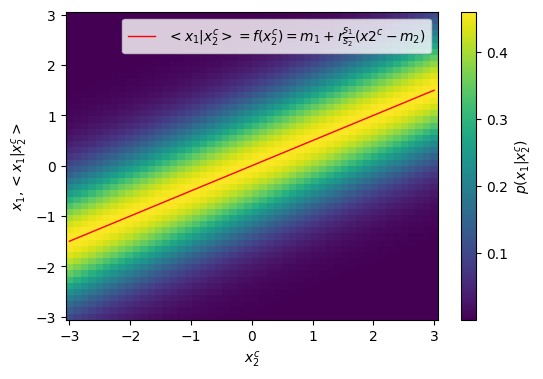

In [17]:
conditional_mean_gauss(
    param = [0, 0, 1, 1, 0.5], #平均1, 2, 標準偏差1, 2, 相関係数
    dom = [[-3,3],[-3,3]]
)

**演習９の考察：**

- 計算結果を整理すると，条件付き期待値は次式となる．
   - $\displaystyle \ave{x_1 | x_2^c} = m_1 + r\frac{s_1}{s_2}(x_2^c - m_2)$
   - 傾き $rs_1/s_2$ の直線を $(m_1,m_2)$ 平行移動したもの．
- そのグラフは，各 $x_2^c$ における条件付き確率密度関数（上のグラフの縦のスライス）の平均を繋いだものになる．ガウス分布なので，平均はピークに位置する．